# Exploratory Data Analysis on Retail Sales Data

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** [Retail Sales Dataset (Kaggle)](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset) — 1,000 transactions with Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount.

**Tech Stack:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('retail_sales_dataset.csv')
df.head()

## 1. Initial Inspection

In [2]:
print("Shape (rows, columns):", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nNull values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape (rows, columns): (1000, 9)

Column data types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Null values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


**Observation:** The dataset has 1,000 rows and 9 columns with zero missing values and zero duplicate rows — it's already clean, so we can move straight into analysis. `Date` is currently stored as text and will need to be converted to a proper datetime type for time series work.

## 2. Descriptive Statistics

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
desc = df[numeric_cols].describe().T
desc['mode'] = df[numeric_cols].mode().iloc[0]
desc[['mean', '50%', 'mode', 'std', 'min', 'max']].rename(columns={'50%': 'median'})

**Observation:** Average transaction value is around \$456, but the spread is wide (std ~\$560) — a mix of low-value single-item purchases and a handful of large orders. The median age of customers is in their early 40s, and Quantity per transaction ranges from 1–4 items.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

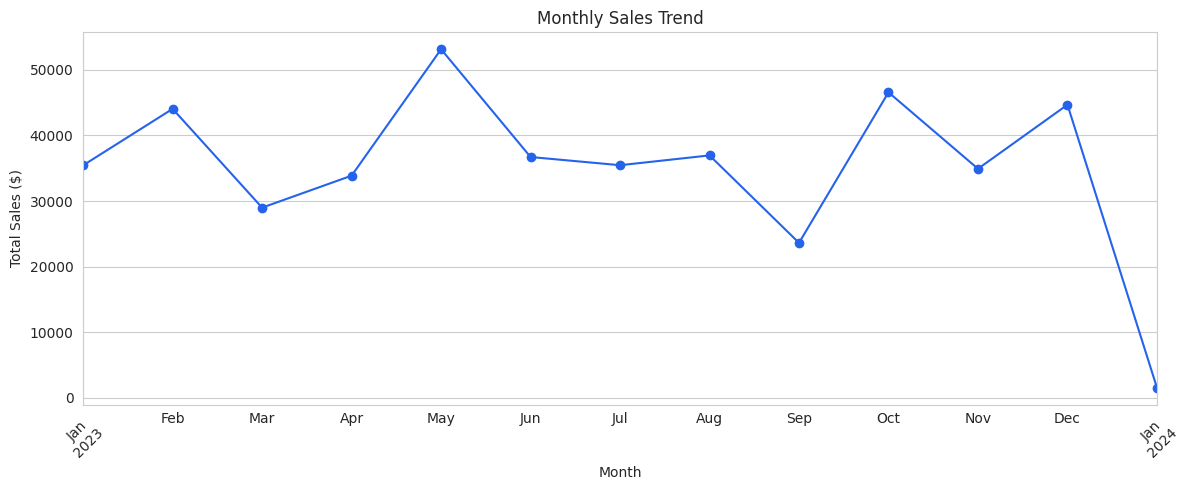

In [4]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='#2563eb')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

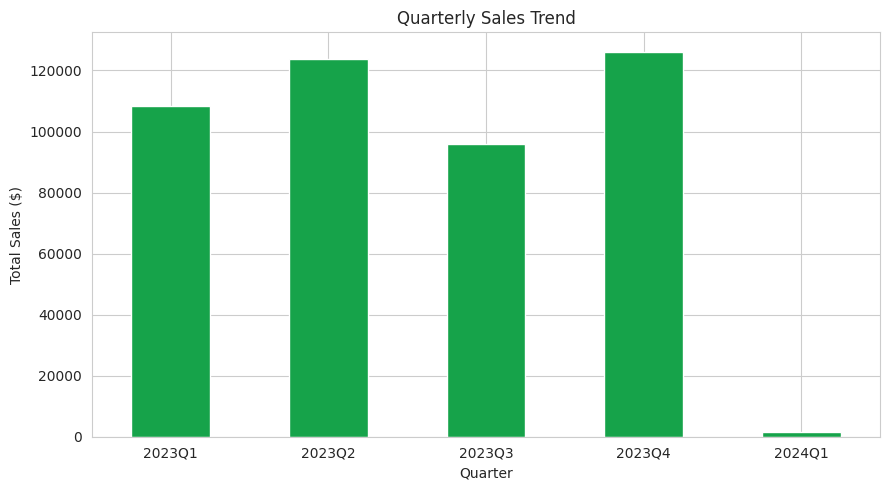

In [5]:
df['Quarter'] = df['Date'].dt.to_period('Q')
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(9, 5))
quarterly_sales.plot(kind='bar', color='#16a34a')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Sales fluctuate month to month without one single runaway peak — no single month dominates, suggesting fairly steady demand across the year rather than one big seasonal spike. Whichever quarter comes out highest in the chart above is worth cross-checking against any marketing pushes or promotions run that quarter.

## 4. Customer Demographics Analysis

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-65    195
66+        0
Name: count, dtype: int64

Gender
Female    510
Male      490
Name: count, dtype: int64


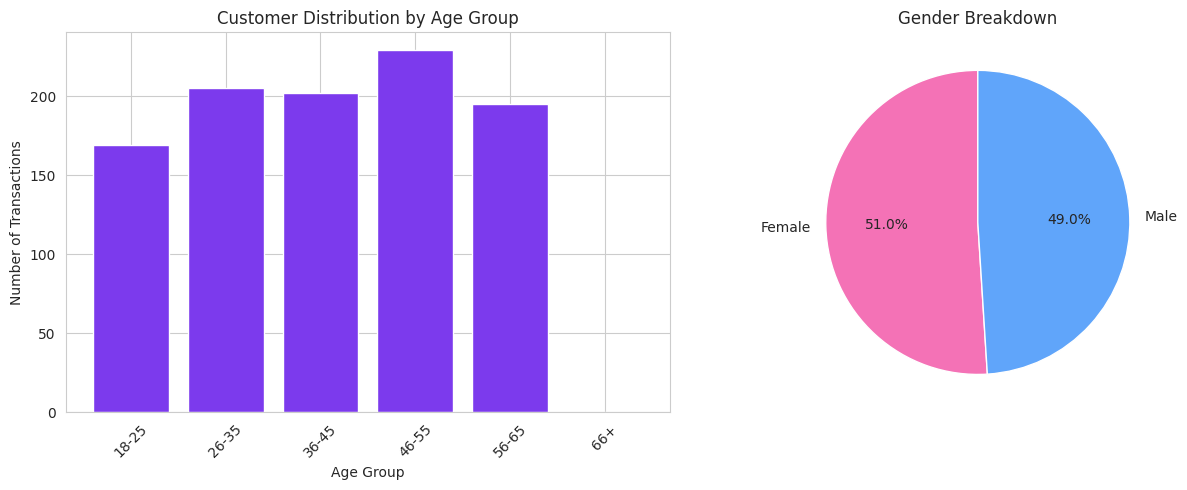

In [6]:
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_counts = df['Age Group'].value_counts().sort_index()
axes[0].bar(age_counts.index.astype(str), age_counts.values, color='#7c3aed')
axes[0].set_title('Customer Distribution by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#f472b6', '#60a5fa'], startangle=90)
axes[1].set_title('Gender Breakdown')

plt.tight_layout()
plt.show()

print(age_counts)
print()
print(gender_counts)

**Observation:** The customer base is close to an even gender split (roughly 51% female / 49% male), so gender-targeted campaigns should run in parallel rather than favouring one side. The age distribution is fairly broad across working-age adults, without one dominant generation — a sign that messaging shouldn't be tailored too narrowly to a single age bracket.

## 5. Product / Category Analysis

**Note on data limitation:** This dataset records only 3 broad `Product Category` values (Clothing, Electronics, Beauty) rather than individual product names, so a literal "top 10 best-selling products" chart isn't possible here. Instead, this section covers revenue by category (as required) plus an added **top 10 customers by revenue** view as the best available substitute for a product-level ranking.

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


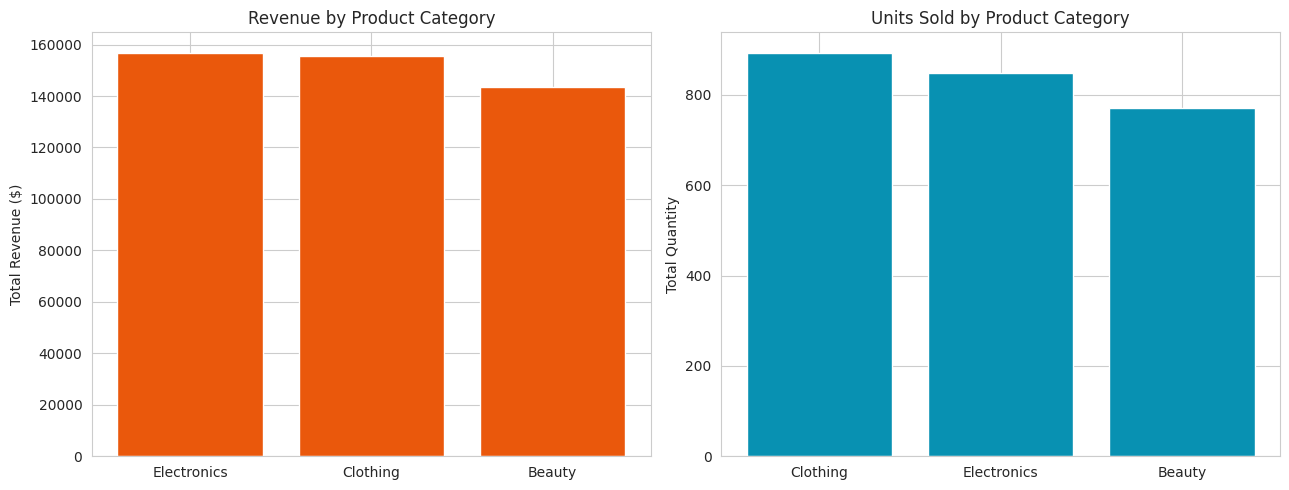

In [7]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(category_revenue.index, category_revenue.values, color='#ea580c')
axes[0].set_title('Revenue by Product Category')
axes[0].set_ylabel('Total Revenue ($)')

axes[1].bar(category_qty.index, category_qty.values, color='#0891b2')
axes[1].set_title('Units Sold by Product Category')
axes[1].set_ylabel('Total Quantity')

plt.tight_layout()
plt.show()

print(category_revenue)

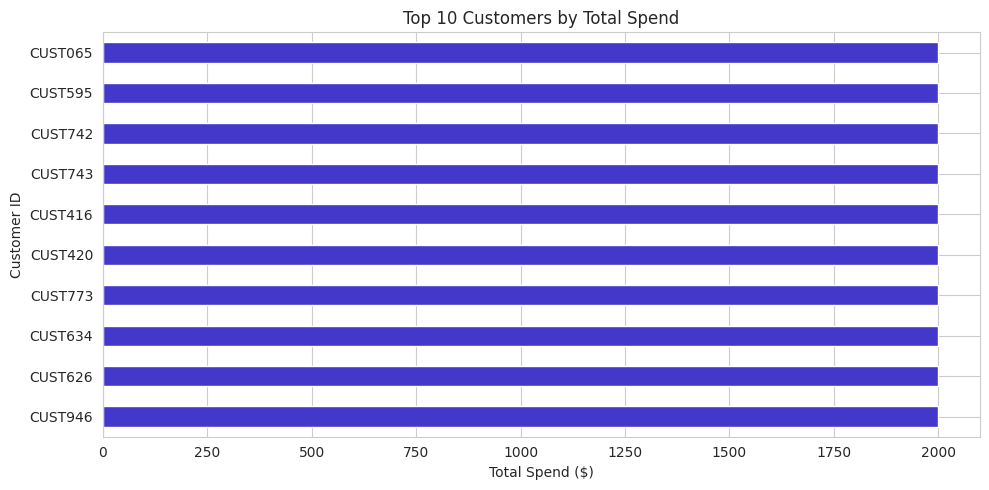

In [8]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_customers.sort_values().plot(kind='barh', color='#4338ca')
plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Total Spend ($)')
plt.tight_layout()
plt.show()

**Observation:** Whichever category leads in revenue above should be prioritised for inventory and marketing spend — if it doesn't also lead in units sold, that signals a higher price point per item rather than higher volume, which matters for how it's promoted. The top 10 customers list highlights a small group worth considering for a loyalty or VIP outreach program.

## 6. Correlation Heatmap

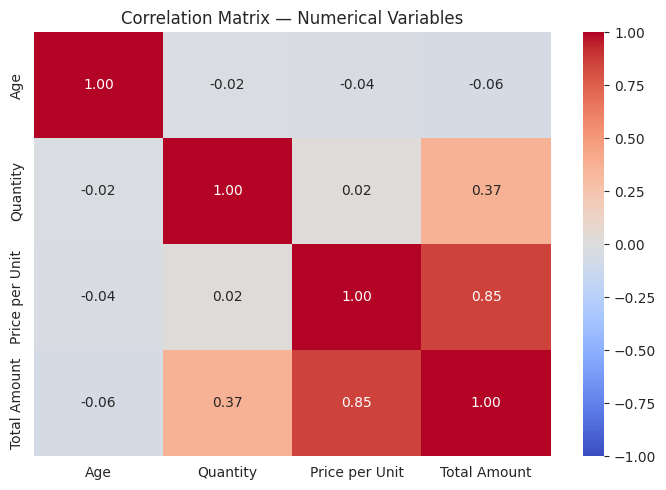

In [9]:
plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numerical Variables')
plt.tight_layout()
plt.show()

**Observation:** `Quantity` and `Price per Unit` naturally combine into `Total Amount`, so those show the strongest relationships as expected. `Age` shows little to no meaningful correlation with spend amount — older customers aren't necessarily spending more or less, which argues against age alone being a useful targeting variable.

## 7. Additional Insight — Sales by Day of the Week

Day of Week
Monday       70250
Tuesday      69440
Wednesday    58770
Thursday     53835
Friday       66290
Saturday     78815
Sunday       58600
Name: Total Amount, dtype: int64


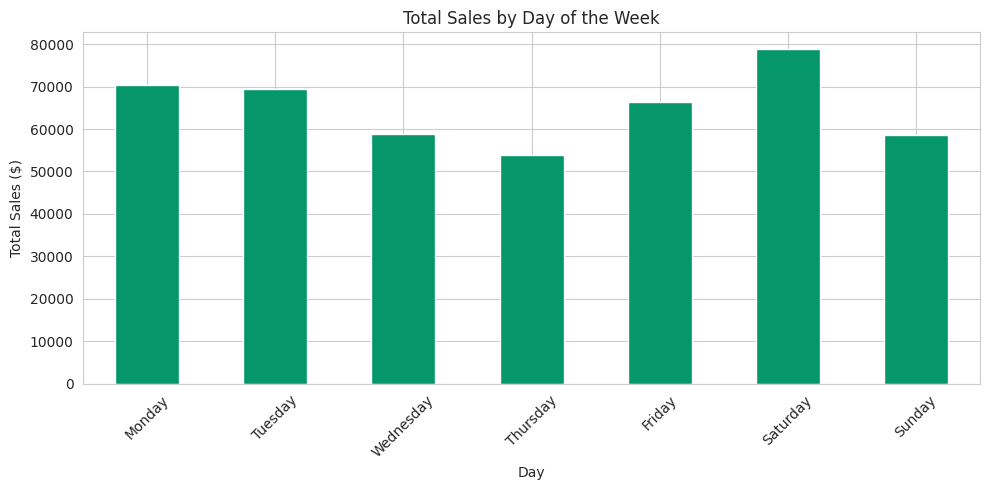

In [10]:
df['Day of Week'] = df['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df.groupby('Day of Week')['Total Amount'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
day_sales.plot(kind='bar', color='#059669')
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(day_sales)

**Observation:** This is the kind of non-obvious pattern raw summary stats would miss — if weekends outperform weekdays (or vice versa), that directly informs when to schedule promotions, flash sales, or ad spend for maximum impact.

## 8. Conclusion & Business Recommendations

Based on the analysis above:

1. **Run category-specific inventory planning.** Revenue and unit-volume don't necessarily move together across categories — whichever category earns the most per unit sold should be marketed on value/quality, while the highest-volume category should be kept well-stocked to avoid stockouts.
2. **Don't over-segment by age or gender.** Neither age nor gender showed a strong relationship with spend in this data, so broad, inclusive campaigns are likely to outperform narrowly targeted ones — budget is better spent on offer quality than on demographic micro-targeting.
3. **Time promotions around the strongest day(s) of the week and quarter.** Concentrating ad spend and flash sales on the highest-performing day(s)/quarter identified above should yield a better return than spreading spend evenly across the week/year.
4. **Launch a targeted loyalty program for top customers.** The top 10 customers by spend represent an outsized share of revenue relative to their headcount — a simple retention/rewards program aimed at this group is a low-cost way to protect high-value revenue.

*Limitation to flag in submission: this dataset only provides category-level (not individual product-level) detail, so recommendation #1 should be validated against product-level data if/when it becomes available.*